# Modelo supervisado de clasificación — Wine dataset
---
**Autor:** Jorge Villacastín Blázquez

Este notebook adapta el ejemplo de clasificación supervisada al Wine Dataset de UCI Machine Learning Repository (ID 109). El objetivo es predecir la clase de un vino (1, 2 o 3) a partir de 13 medidas físico-químicas.

El trabajo sigue los cuatro bloques solicitados: **EDA**, **ingeniería/preparación de características**, **construcción del modelo** y **evaluación de resultados**.

## 0 - Importación de librerías
Utilizaremos ucimlrepo para cargar directamente el Wine Dataset (ID 109) desde UCI Machine Learning Repository y XGBoost para construir el modelo de clasificación supervisada multiclase.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo

!pip install -q xgboost
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

pd.options.display.max_columns = 100
RANDOM_STATE = 42


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# 1 - Carga, preparación y EDA de los datos
## 1.1 - Carga del dataset
El Wine Dataset de UCI (ID 109) contiene 178 observaciones, 13 variables numéricas y una variable objetivo (class) con 3 clases. Cada fila representa una muestra de vino y las variables recogen resultados de análisis químicos.

In [48]:
# Cargamos el Wine Dataset de UCI (ID 109)
wine = fetch_ucirepo(id=109)

# Variables predictoras
X = wine.data.features.copy()

# Variable objetivo
y = wine.data.targets.copy().squeeze()

# Dataset completo para realizar el análisis exploratorio (EDA)
df = X.copy()
df['class'] = y

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Dimensiones del dataset completo: {df.shape}")

display(df.head())

Dimensiones de X: (178, 13)
Dimensiones de y: (178,)
Dimensiones del dataset completo: (178, 14)


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


## 1.2 - Comprensión del problema
A diferencia del ejemplo original del censo, aquí tenemos una **clasificación multiclase**: la variable objetivo `class` puede tomar los valores 1, 2 o 3. Las 13 variables predictoras son numéricas, por lo que no necesitamos codificar variables categóricas.

In [49]:
feature_info = pd.DataFrame({
    'variable': X.columns,
    'tipo': ['numérica'] * X.shape[1]
})

feature_info

,variable,tipo
0,Alcohol,numérica
1,Malicacid,numérica
2,Ash,numérica
3,Alcalinity_of_ash,numérica
4,Magnesium,numérica
5,Total_phenols,numérica
6,Flavanoids,numérica
7,Nonflavanoid_phenols,numérica
8,Proanthocyanins,numérica
9,Color_intensity,numérica


## 1.3 - Exploración inicial
Comprobamos tipos de datos, valores ausentes, estadísticos descriptivos y distribución de la variable objetivo.

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
 13  class           

In [51]:
print("Valores ausentes por columna:")
display(df.isna().sum().to_frame('nulos'))

print("Duplicados:", df.duplicated().sum())

Valores ausentes por columna:


,nulos
Alcohol,0
Malicacid,0
Ash,0
Alcalinity_of_ash,0
Magnesium,0
Total_phenols,0
Flavanoids,0
Nonflavanoid_phenols,0
Proanthocyanins,0
Color_intensity,0


Duplicados: 0


In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malicacid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [53]:
class_counts = df['class'].value_counts().sort_index()
class_percent = df['class'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'n': class_counts, 'porcentaje': class_percent.round(2)})

,n,porcentaje
class,,
1,59,33.15
2,71,39.89
3,48,26.97


### Interpretación inicial
El dataset es pequeño y limpio: no requiere imputación de valores ausentes. Las tres clases no tienen exactamente el mismo tamaño, pero ninguna es extremadamente minoritaria. Por ello, además de `accuracy`, revisaremos las métricas por clase mediante `classification_report`.

## 1.4 - Análisis gráfico
Primero observamos la distribución de las variables. Después analizamos correlaciones para identificar relaciones lineales entre características y con la variable `class`.

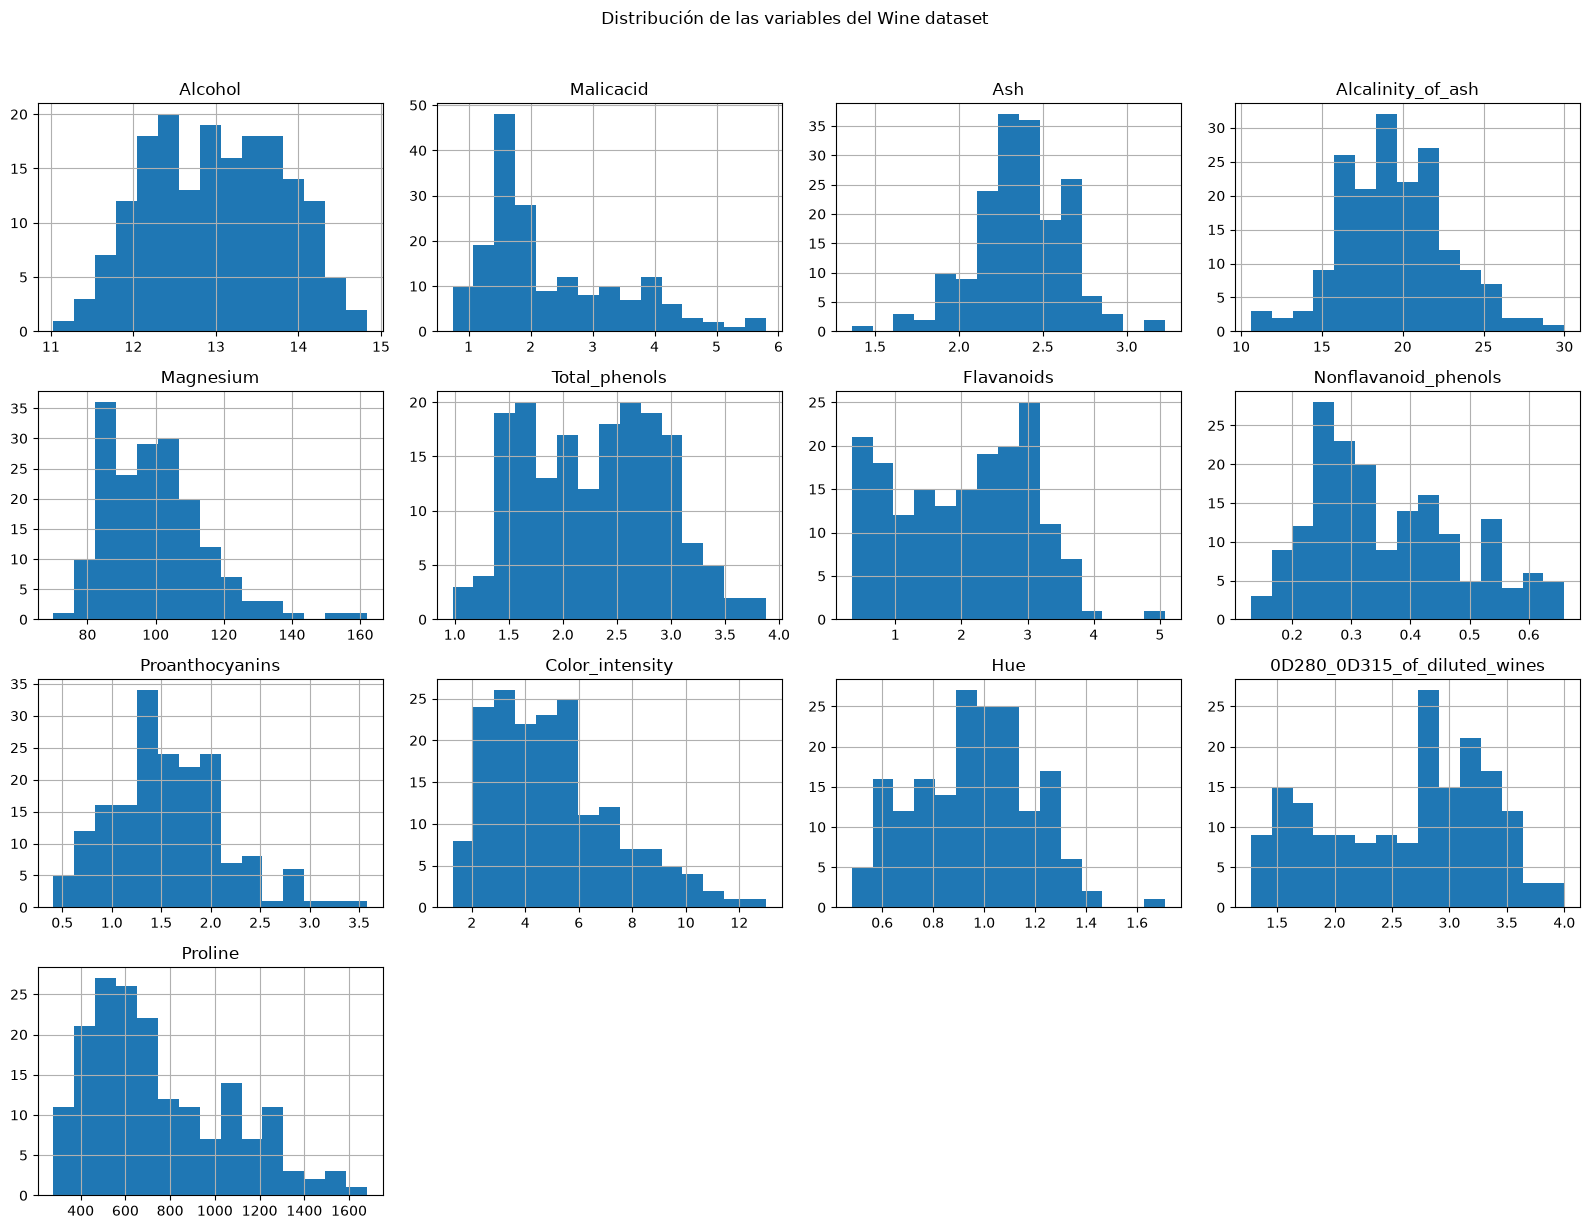

In [54]:
df.drop(columns='class').hist(figsize=(16, 12), bins=15)
plt.suptitle('Distribución de las variables del Wine dataset', y=1.02)
plt.tight_layout()
plt.show()

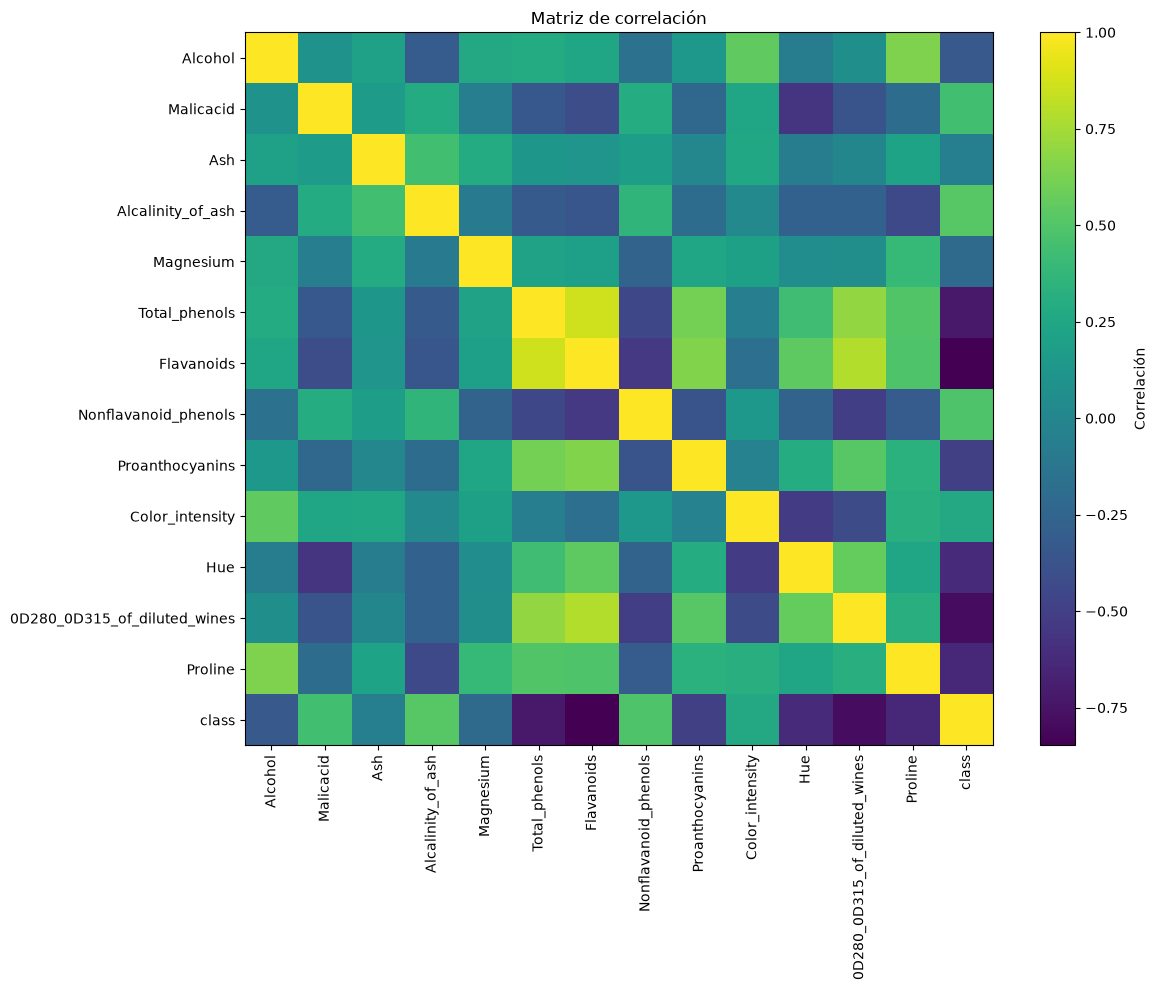

In [55]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax, label='Correlación')
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [56]:
corr_target = corr['class'].drop('class').sort_values(key=abs, ascending=False)
corr_target.to_frame('correlación con class')

,correlación con class
Flavanoids,-0.847498
0D280_0D315_of_diluted_wines,-0.788230
Total_phenols,-0.719163
Proline,-0.633717
Hue,-0.617369
Alcalinity_of_ash,0.517859
Proanthocyanins,-0.499130
Nonflavanoid_phenols,0.489109
Malicacid,0.437776
Alcohol,-0.328222


### Nota sobre la correlación con `class`

La variable `class` está codificada numéricamente, pero sus valores representan etiquetas de clase, no una magnitud continua. Por tanto, estas correlaciones se muestran únicamente con fines exploratorios y no deben interpretarse como relaciones causales ni como una relación ordinal entre las clases.

# 2 - Procesado e ingeniería de características

En este dataset la preparación necesaria es sencilla:
- no existen variables categóricas que sea necesario codificar;
- no hay valores ausentes que imputar;
- todas las variables predictoras son numéricas;
- XGBoost es un algoritmo basado en árboles, por lo que no requiere estandarización de las variables.

La variable objetivo original utiliza las etiquetas 1, 2 y 3. Para el entrenamiento con XGBoost se recodifican temporalmente como 0, 1 y 2, manteniendo las etiquetas originales para la interpretación de los resultados.

Posteriormente se divide el dataset en conjuntos de entrenamiento (80 %) y test (20 %) mediante una partición estratificada, conservando aproximadamente la proporción de cada clase.

In [57]:
X = df.drop(columns='class')
y = df['class']

# X contiene las 13 características
# y_model contiene las clases 0, 1 y 2 para XGBoost
y_model = y - 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142, 13)
X_test: (36, 13)
y_train: (142,)
y_test: (36,)


# 3 - Construcción y entrenamiento del modelo
Utilizamos XGBoost (XGBClassifier) para resolver el problema de clasificación multiclase. XGBoost construye secuencialmente un conjunto de árboles de decisión, donde cada nuevo árbol trata de corregir los errores cometidos por los anteriores.
Se configura objective='multi:softprob' para clasificación multiclase y num_class=3, correspondiente a las tres clases presentes en el dataset.

In [58]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

# 4 - Evaluación del modelo
Evaluamos sobre el 20 % de datos que el modelo no ha utilizado durante el entrenamiento.

In [59]:
y_pred = model.predict(X_test)

y_test_original = y_test + 1
y_pred_original = y_pred + 1

accuracy = accuracy_score(y_test_original, y_pred_original)

print(f"Accuracy: {accuracy:.4f}")
print()
print("Classification report:")
print(
    classification_report(
        y_test_original,
        y_pred_original,
        target_names=['Clase 1', 'Clase 2', 'Clase 3']
    )
)

Accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

     Clase 1       1.00      1.00      1.00        12
     Clase 2       1.00      1.00      1.00        14
     Clase 3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 4.1 - Validación cruzada

Dado el reducido tamaño del dataset y el resultado del 100 % obtenido
sobre el conjunto de test, realizamos adicionalmente una validación
cruzada estratificada de 5 folds para obtener una estimación más robusta
de la capacidad de generalización del modelo.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y_model,
    cv=cv,
    scoring='accuracy'
)

print("Accuracy por fold:", cv_scores)
print(f"Accuracy media: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

train_accuracy = accuracy_score(
    y_train,
    model.predict(X_train)
)

test_accuracy = accuracy_score(
    y_test,
    model.predict(X_test)
)

print(f"Accuracy entrenamiento: {train_accuracy:.4f}")
print(f"Accuracy test:          {test_accuracy:.4f}")

Accuracy por fold: [0.97222222 0.94444444 0.97222222 0.91428571 1.        ]
Accuracy media: 0.9606
Desviación estándar: 0.0291
Accuracy entrenamiento: 1.0000
Accuracy test:          1.0000


Aunque el conjunto de test seleccionado obtiene una accuracy del 100 %, el dataset contiene únicamente 178 observaciones y el test está formado por 36 muestras. Por tanto, una única partición puede proporcionar una estimación demasiado optimista.

La validación cruzada estratificada de 5 folds obtiene una accuracy media aproximada del 96,1 %, con una desviación estándar de aproximadamente 2,9 puntos porcentuales. Esto indica que el modelo mantiene un rendimiento elevado en diferentes particiones de los datos, aunque no alcanza sistemáticamente el 100 %.

La diferencia entre el 100 % obtenido en entrenamiento y test para la partición concreta y los resultados de validación cruzada aconseja interpretar el resultado del test con cautela. No obstante, la validación cruzada sugiere una buena capacidad de generalización del modelo.

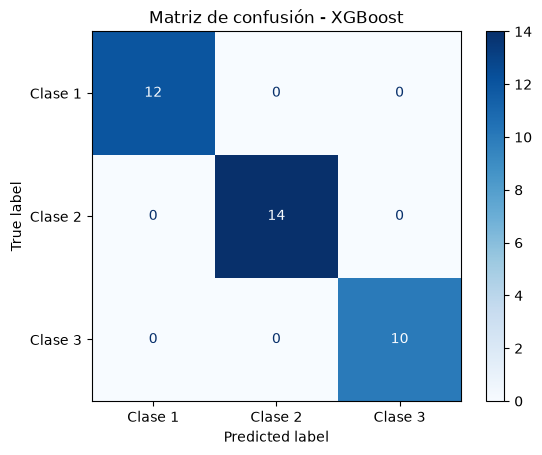

In [61]:
ConfusionMatrixDisplay.from_predictions(
    y_test_original,
    y_pred_original,
    display_labels=['Clase 1', 'Clase 2', 'Clase 3'],
    cmap='Blues'
)

plt.title('Matriz de confusión - XGBoost')
plt.show()

## 4.2 - Importancia de las características
XGBoost permite estimar la importancia relativa de las variables utilizadas durante la construcción de los árboles. Analizamos estas importancias para identificar qué características han tenido mayor influencia en las decisiones del modelo.

Estas importancias reflejan la utilización de las variables por el modelo y no deben interpretarse como relaciones causales.

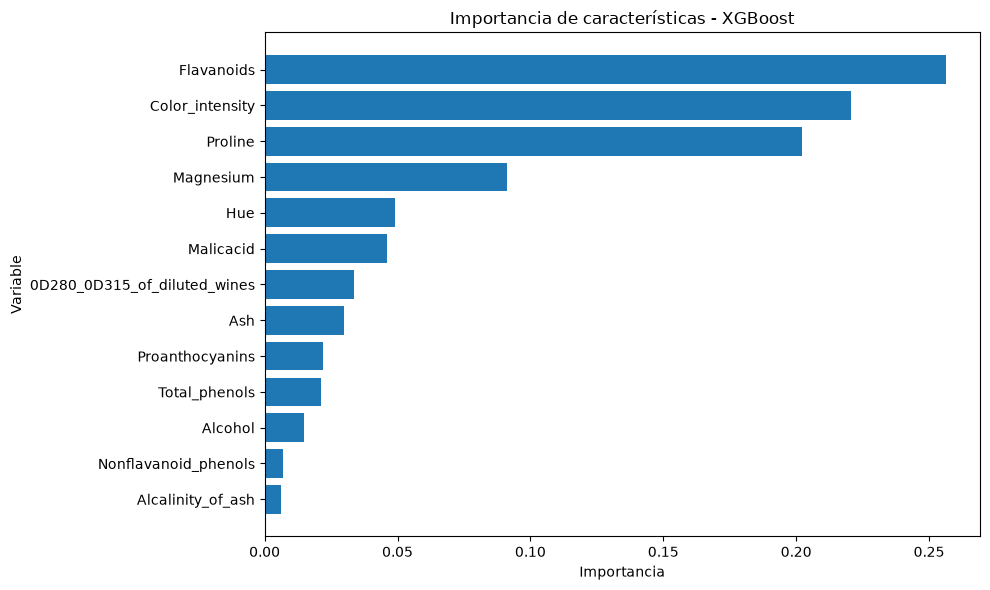

In [62]:
feature_importance = pd.DataFrame({
    'variable': X.columns,
    'importancia': model.feature_importances_
}).sort_values(
    'importancia',
    ascending=False
)

feature_importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['variable'],
    feature_importance['importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de características - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5 - Conclusión
En este ejercicio se ha desarrollado un modelo de clasificación supervisada multiclase utilizando el Wine Dataset de UCI. Tras realizar el análisis exploratorio de los datos, se comprobó que el dataset contiene 178 observaciones, 13 variables predictoras numéricas y tres clases, sin valores ausentes ni registros duplicados.

Los datos se dividieron de forma estratificada en conjuntos de entrenamiento y test y se entrenó un modelo XGBoost para predecir la clase de cada vino a partir de sus características físico-químicas.

En la partición utilizada, el modelo obtuvo una accuracy del **100** % sobre las 36 muestras del conjunto de test, clasificando correctamente las tres clases. Sin embargo, debido al reducido tamaño del dataset, este resultado aislado puede ofrecer una estimación demasiado optimista de la capacidad de generalización.

Por este motivo, se realizó adicionalmente una validación cruzada estratificada de 5 folds, obteniendo una accuracy media de aproximadamente 96,1 %, con una desviación estándar aproximada del 2,9 %. Estos resultados muestran que el modelo mantiene un rendimiento elevado en diferentes particiones de los datos, aunque no alcanza sistemáticamente el 100 %.

Finalmente, se analizó la importancia de las características proporcionada por XGBoost para estudiar qué variables tienen mayor influencia en las predicciones del modelo.